<h1 style="color:orange; font-weight:bold">🚀 Boosting</h1>

<div align="center">

<img src="16_xgboost.png" alt="Missing Values Handling — From Basic to Advanced" width="100%">

</div>

**Boosting is an Ensemble Learning technique that combines multiple weak learners sequentially to build a strong learner.**

Instead of building all models independently, Boosting learns **step-by-step from previous mistakes**.

### 🧠 How Does Boosting Work?

1. 🌱 **Start with a weak learner** → Train the first simple model.
2. ❌ **Find the mistakes** → Identify incorrectly predicted samples.
3. 🎯 **Focus on mistakes** → Give more importance to difficult/misclassified samples.
4. 🔄 **Train the next learner** → The new model focuses more on previous errors.
5. 🤝 **Repeat & Combine** → Multiple weak learners are combined into one strong model.

### 📚 Types of Boosting

* ⚡ **AdaBoost (Adaptive Boosting)**
* 📈 **Gradient Boosting**
* 🎲 **Stochastic Gradient Boosting**
* 🌳 **XGBoost (Extreme Gradient Boosting)**
* 🚀 **LightGBM**
* 🐱 **CatBoost (Categorical Boosting)**
* 📐 **LPBoost (Linear Programming Boosting)**
* 🔥 **TotalBoost**

### 🎯 Our Main Focus: XGBoost

In this notebook, our **main practical focus will be XGBoost**.

We will train an **XGBoost model** and compare its performance with other selected models to understand how it performs on the same dataset.

> 💡 **Rule:**
> **Boosting → Learn sequentially from mistakes → Combine weak learners → Build a strong learner.**
---


<h1 style="color:RED; font-weight:bold">🚀 XGBoost</h1>

**XGBoost (Extreme Gradient Boosting)** is a powerful and optimized **Gradient Boosting** algorithm.

It builds decision trees **sequentially**, where each new tree tries to improve the errors made by the previous trees.

### 🎯 XGBoost Can Handle

* 🏷️ **Classification** → Predicts categories/classes
* 📈 **Regression** → Predicts continuous numerical values

### 🏷️ XGBoost Classifier

Used when the target is **categorical**.

**Example:**

`Customer Data → XGBoost Classifier → Fraud / Not Fraud`

### 📈 XGBoost Regressor

Used when the target is **continuous numerical**.

**Example:**

`House Features → XGBoost Regressor → House Price`

> 💡 **Remember:**
> **XGBClassifier → Class/Category 🏷️**
> **XGBRegressor → Numerical Value 🔢**


In [19]:
# Install 'xgboot' Liberary
# !pip install xgboost -q

In [20]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier         # First Model
from sklearn.ensemble import RandomForestClassifier     # Second Model
from xgboost import XGBClassifier                       # Third Model

In [21]:
# Load the Data
df = sns.load_dataset('diamonds')

In [22]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [23]:
df.shape

(53940, 10)

## 🏆 Classification Model Comparison

🌳 **Decision Tree Classifier**  
🌲 **Random Forest Classifier — Bagging**  
🚀 **XGBoost Classifier — Boosting**

> 🎯 **Train → Evaluate → Compare Performance**

In [24]:
# Split the Data into X and y
X = df.drop('cut', axis=1)
y = df['cut']

# Encode the input Variables
le = LabelEncoder()
X['color'] = le.fit_transform(X['color'])
X['clarity'] = le.fit_transform(X['clarity'])

# Encode the Target Variable
y = le.fit_transform(y)

# Split the Data into Train & Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

<h3 style="color:orange; font-weight:bold">🌳 Decision Tree Classifier</h3>

In [25]:
%%time
# Train the Decision Tree Model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Predict the Test Data
y_pred = dt.predict(X_test)

print('Accuracy score: ', accuracy_score(y_test, y_pred))
print('Precision score: ', precision_score(y_test, y_pred, average='micro'))
print('Recall score: ', recall_score(y_test, y_pred, average='micro'))
print('F1 score: ', f1_score(y_test, y_pred, average='micro'))

Accuracy score:  0.7195958472376714
Precision score:  0.7195958472376714
Recall score:  0.7195958472376714
F1 score:  0.7195958472376714
CPU times: total: 547 ms
Wall time: 564 ms


<h3 style="color:orange; font-weight:bold">🌲 Random Forest Classifier — Bagging</h3>

In [26]:
%%time
# Train the Random Forest Model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Predict the Test Data
y_pred = rf.predict(X_test)

print('Accuracy score: ', accuracy_score(y_test, y_pred))
print('Precision score: ', precision_score(y_test, y_pred, average='micro'))
print('Recall score: ', recall_score(y_test, y_pred, average='micro'))
print('F1 score: ', f1_score(y_test, y_pred, average='micro'))

Accuracy score:  0.7925472747497219
Precision score:  0.7925472747497219
Recall score:  0.7925472747497219
F1 score:  0.7925472747497219
CPU times: total: 12.1 s
Wall time: 13.8 s


<h3 style="color:orange; font-weight:bold">🚀 XGBoost Classifier — Boosting</h3>

In [27]:
%%time
# Train the XGBoost Model
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Predict the Test Data
y_pred = xgb.predict(X_test)

print('Accuracy score: ', accuracy_score(y_test, y_pred))
print('Precision score: ', precision_score(y_test, y_pred, average='micro'))
print('Recall score: ', recall_score(y_test, y_pred, average='micro'))
print('F1 score: ', f1_score(y_test, y_pred, average='micro'))

Accuracy score:  0.8109936967000371
Precision score:  0.8109936967000371
Recall score:  0.8109936967000371
F1 score:  0.8109936967000371
CPU times: total: 8.23 s
Wall time: 2.3 s


<h3 style="color:orange; font-weight:bold">Comparison</h3>

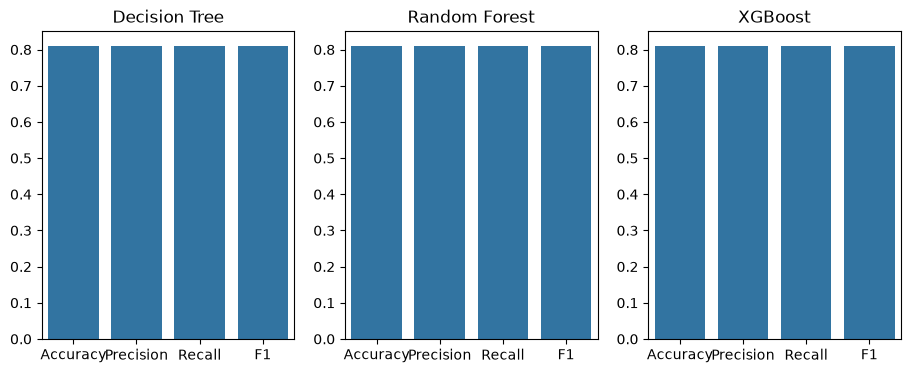

In [28]:
# Bar Plot Showing Each of the Matrix with Respect to the Model
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('Decision Tree')
plt.subplot(1, 4, 2)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('Random Forest')
plt.subplot(1, 4, 3)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('XGBoost')
# plt.tight_layout()
plt.show()